In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
print(y.shape)

X.head()

(569, 30)
(569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

In [6]:
model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1),
    nn.Sigmoid()
)

In [7]:
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 100
history = []

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    history.append(loss.item())

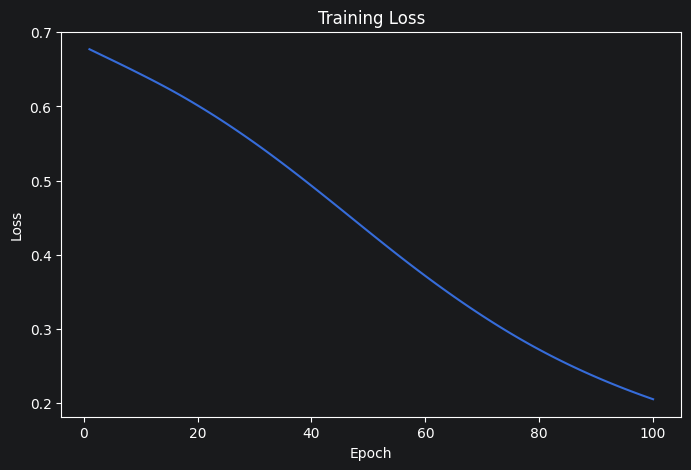

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs + 1), history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [10]:
model.eval()

with torch.no_grad():

    predictions = model(X_test_tensor)
    predictions = (predictions >= 0.5).int()

accuracy = accuracy_score(y_test, predictions.numpy())

f1 = f1_score(y_test, predictions.numpy())

print("Accuracy:", round(accuracy,3))
print("F1-score:", round(f1,3))

Accuracy: 0.912
F1-score: 0.929


In [11]:
results = pd.DataFrame({"Real": y_test.values, "Predicted": predictions.numpy().flatten()})
results.head(10)

,Real,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


Використано багатошарову нейронну мережу (MLP) для класифікації датасету Breast Cancer. Після навчання модель показала високу точність та значення F1-score, що свідчить про успішне навчання. Отримані результати значно кращі, ніж випадкове передбачення.